# Iterative BME


When dealing with SAXS data it is possible to fit the weights and the parameters in the linear regression iteratively. This can be done automatically by calling the function ibme().


Assume $F^{(0)}_{j,i}$ are $i=1\cdots m$ observables calculated on $j=1\cdots N$ frames. Each frame has an initial weight $w_j^{(0)}$. For each observation, $F_{i}^{\text{EXP}}$ is the corresponding experimental measure. 

The iterative BME procedure consists in the following steps:

  1. Calculate ensemble average $\langle F \rangle^{(k)} = \sum_{j}w_j^{(k)} F^{(k)}_{j,i}$
  2. Perform a linear regression, and determine the optimal parameters $\alpha^{(k)},\beta^{(k)}  = fit(\langle F \rangle ^{(k)},F_j^{\text{CALC}})$
  3. Transform the dataset $F_{j,i}^{(k+1)} =  \alpha^{(k)} F^{(k)}_{j,i} + \beta^{(k)} $
  4. Perform a BME fit and calculate the optimal parameters $w^{(k+1)} = BME(F^{(k+1)},w^{(0)}) $
  5. Iterate over 1-4 until the procedure converges, i.e. the improvement over the optimized $\chi^2$ drops below a tolerance value `ftol`
  

In [1]:
import sys,os
import numpy as np
bme_dir = '/home/courtade/BME2/'
sys.path.append(bme_dir)
import BME as BME
import matplotlib.pyplot as plt

In [ ]:
# define input file names
exp_file = "exp_data.dat"
calc_file = "calc_data_MD.dat"
name = "Cys"
#calc_saxs.txt.zip
# initialize. A name must be specified 
rew = BME.Reweight(name)

# load the experimental and calculated datasets
rew.load(exp_file,calc_file)

    


In [3]:

thetas = [0.1,1,10,100,1000]
do = False

if do:


    fig, ax = plt.subplots(figsize=(20, 10))
    chi2 = []
    phis = []
    for t in thetas:
        print("Running with theta={}".format(t))
        X = rew.ibme(theta=t,iterations=50,ftol=0.02,offset=True)
        chi2_before, chi2_after, phi = X[0], X[1], X[2]
        phis.append(phi)
        chi2.append(chi2_after/chi2_before)
        print("Chi2 before BME %.2f" % chi2_before)
        print("Chi2 after  BME %.2f" % chi2_after)
        print("Fraction of effective frames %.2f" % phi)
        #(t,chi2_after/chi2_before,c="k")
        plt.scatter(t,phi,c="r")
    with open('theta_analysis.csv', 'w') as f:
        f.write("#Theta, Phi, Chi2\n")
        for t, phi, chi in zip(thetas, phis, chi2):
            f.write("{},{},{}\n".format(t, phi, chi))
    plt.plot(thetas,phis,"-o",label="Phi",c="k")
    plt.plot(thetas,chi2,"-o",label="Chi2 reduction",c="r")
    plt.legend()
    plt.xscale('log')
    plt.xlabel("Theta")

In [4]:
theta=10

# initialize. A name must be specified 
rew = BME.Reweight(name)

# load the experimental and calculated datasets
rew.load(exp_file,calc_file)

# fit the data 
X = rew.ibme(theta=theta,iterations=50,ftol=0.02,offset=True)
chi2_before, chi2_after, phi = X[0], X[1], X[2]

# print statistics
print("Chi2 before BME %.2f" % chi2_before)
print("Chi2 after  BME %.2f" % chi2_after)
print("Fraction of effective frames %.2f" % phi)

Iterative procedure converged below tolerance 1.84e-02 after 12 iterations
Chi2 before BME 8.01
Chi2 after  BME 1.00
Fraction of effective frames 0.54


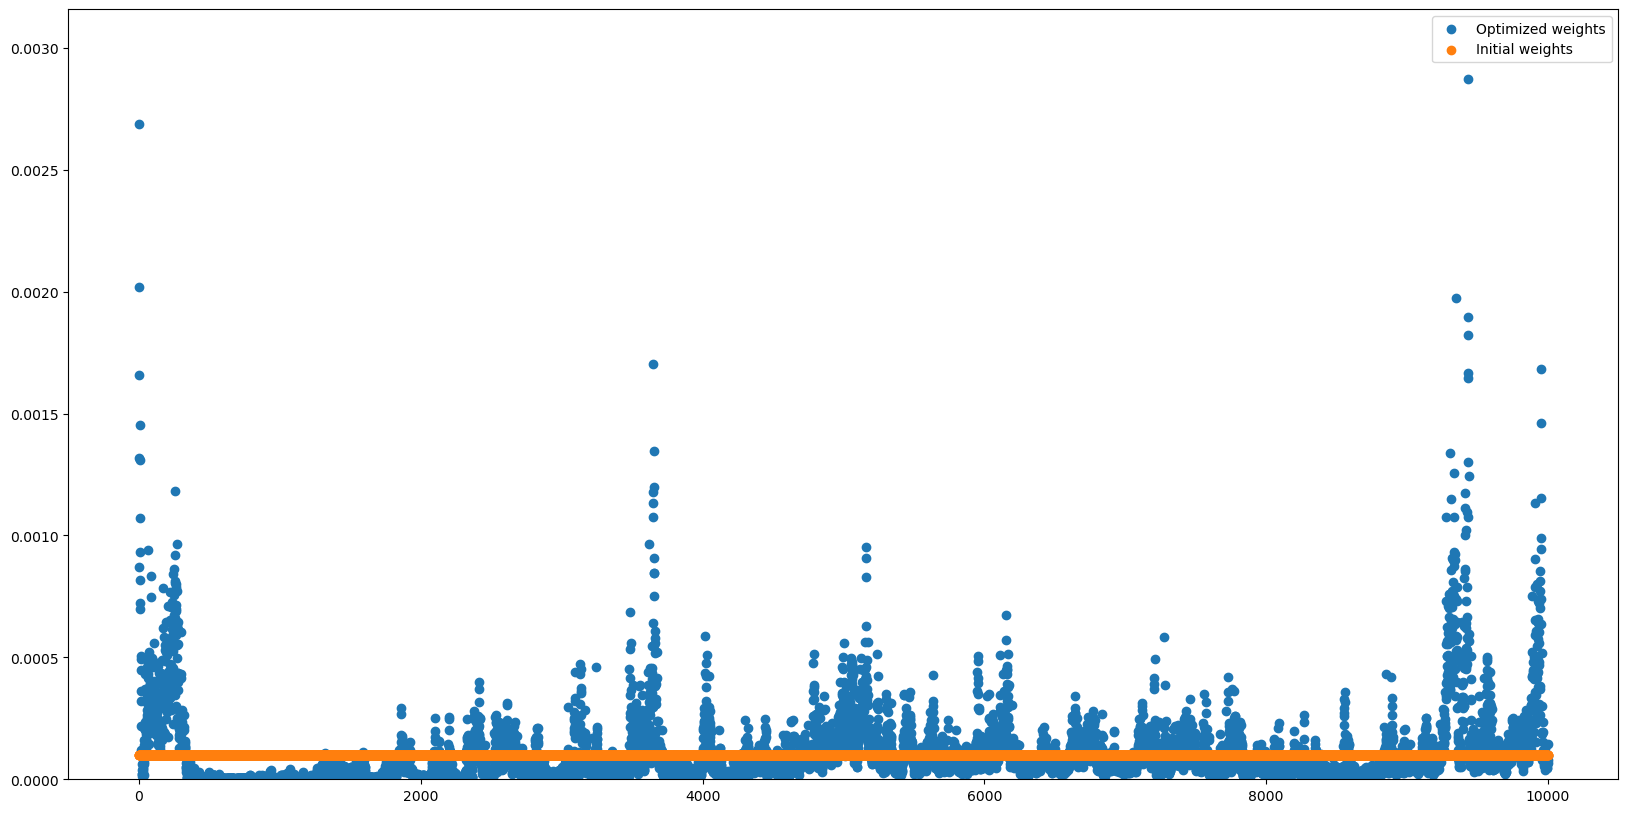

Frames with 10 highest weights: [9432    1    2 9350 9436 9434 3652 9951 9433    3 9435 9952    8 3653
 9303    4    6 9431 9337 9437]


In [5]:
w0 = rew.get_w0()
w_new = rew.get_weights()

fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(len(w0)),w_new,label="Optimized weights")
plt.scatter(range(len(w0)),w0,label="Initial weights")
plt.ylim(0,w_new.max()*1.1)
plt.legend()
plt.show()
plt.close()

print('Frames with 10 highest weights:', w_new.argsort()[::-1][:20]+1)

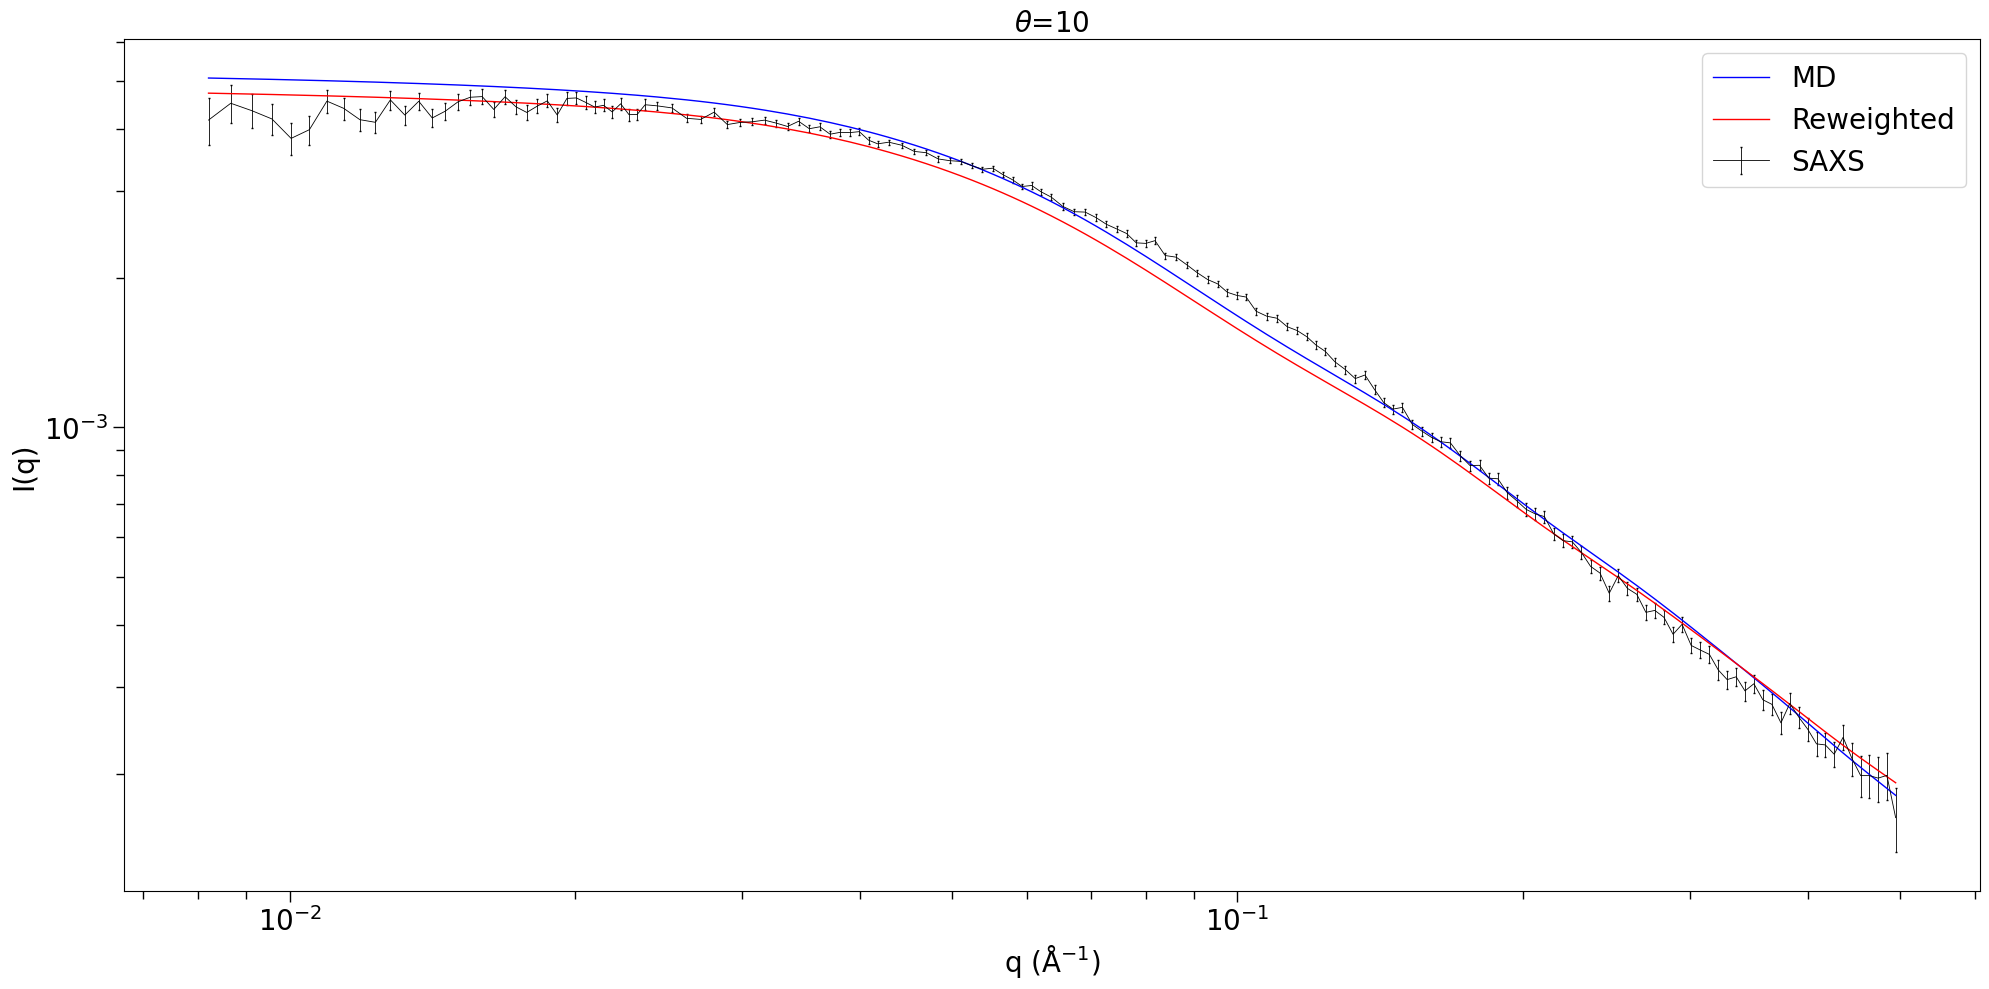

In [ ]:
stats = rew.predict(exp_file,calc_file,name)
data = np.loadtxt(name)

x = data[:,0]
avg_exp = data[:,1]
sigma_exp = data[:,2]
avg_calc = X[3].mean(axis=0)
avg_calc_rew = X[4].mean(axis=0)

with open('data.dat', 'w') as f:
    f.write('# label exp_avg exp_sigma calc_avg calc_avg_rew\n')
    for i,j,k,l,m in zip(x,avg_exp,sigma_exp,avg_calc, avg_calc_rew):
        f.write("%.6f\t%.3e\t%.3e\t%.3e\t%.3e\n" % (i,j,k,l,m))


fig, ax = plt.subplots(figsize=(20, 10))
plt.errorbar(x, avg_exp, yerr=sigma_exp, ecolor='black', capsize=0.6, linewidth=0.6, color='black', label='SAXS')
plt.plot(x, avg_calc,linewidth=1, color='blue', label='MD')
plt.plot(x, avg_calc_rew,linewidth=1, color='red', label='Reweighted')

#plt.fill_between(x, avg_exp-sigma_exp, avg_exp+sigma_exp, color='grey')
fs = 20
ax.tick_params(axis='both', which='major', width=1, length=8)
ax.tick_params(axis='both', which='minor', width=1, length=6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'q (Å$^{-1}$)', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylabel('I(q)', fontsize=fs)
plt.legend(fontsize=fs)
plt.title(r'$\theta$={}'.format(theta), fontsize=fs)
plt.tight_layout()
# plt.savefig('SAXS_fit.png', dpi=300)
plt.show()
 

In [7]:
# Create CDF
cdf = np.cumsum(w_new)
conformations = w_new.argsort()

# Random sampling
num_samples = 100
random_numbers = np.random.rand(num_samples)
sampled_conformations = [conformations[np.searchsorted(cdf, rn)] for rn in random_numbers]

In [8]:
sampled_conformations

[np.int64(2689),
 np.int64(4754),
 np.int64(1877),
 np.int64(704),
 np.int64(6602),
 np.int64(5125),
 np.int64(801),
 np.int64(268),
 np.int64(3261),
 np.int64(1889),
 np.int64(1295),
 np.int64(9103),
 np.int64(1011),
 np.int64(5070),
 np.int64(4523),
 np.int64(6258),
 np.int64(2052),
 np.int64(2689),
 np.int64(5308),
 np.int64(3833),
 np.int64(5052),
 np.int64(7453),
 np.int64(8857),
 np.int64(4730),
 np.int64(479),
 np.int64(583),
 np.int64(2566),
 np.int64(3986),
 np.int64(9842),
 np.int64(1592),
 np.int64(5662),
 np.int64(603),
 np.int64(8129),
 np.int64(6677),
 np.int64(6003),
 np.int64(1129),
 np.int64(632),
 np.int64(8271),
 np.int64(6792),
 np.int64(7510),
 np.int64(7596),
 np.int64(79),
 np.int64(3257),
 np.int64(964),
 np.int64(6843),
 np.int64(4214),
 np.int64(5084),
 np.int64(5094),
 np.int64(9318),
 np.int64(4378),
 np.int64(7689),
 np.int64(85),
 np.int64(9911),
 np.int64(2137),
 np.int64(3264),
 np.int64(9142),
 np.int64(8050),
 np.int64(2848),
 np.int64(261),
 np.int64(

In [9]:
# use pymol to read each of the frames in sampled_conformations and join them into one pdb file
cmd_str = '/home/courtade/pymol/pymol -c -l make_ensemble.pml'
with open('make_ensemble.pml', 'w') as f:
    for i in sampled_conformations:
        f.write(f"load /home/courtade/Documents/2024_AA14-peptide/simulation/structure/dimer/post_process/all_frames/frame{i}.pdb\n")
    f.write('join_states ensemble, frame*\n')
    f.write('alter ensemble and id 1-415, chain="A"\n')
    f.write('alter ensemble and id 416-830, chain="B"\n')
    f.write('save /home/courtade/Documents/2024_AA14-peptide/simulation/structure/dimer/post_process/ensemble.pdb, ensemble, 0')
os.system(cmd_str)

 PyMOL(TM) 3.1.5.1 - Incentive Product
 Copyright (C) Schrodinger, LLC
 
 This Executable Build integrates and extends Open-Source PyMOL.
 Detected 8 CPU cores.  Enabled multithreaded rendering.
PyMOL>spawn make_ensemble.pml
PyMOL>load /home/courtade/Documents/2024_AA14-peptide/simulation/structure/dimer/post_process/all_frames/frame2689.pdb
TITLE     Protein in water t= 268900.00000 step= 134450000
TITLE     Protein in water t= 268900.00000 step= 134450000
 ObjectMolecule: Read crystal symmetry information.
 CmdLoad: "" loaded as "frame2689".
PyMOL>load /home/courtade/Documents/2024_AA14-peptide/simulation/structure/dimer/post_process/all_frames/frame4754.pdb
TITLE     Protein in water t= 475400.00000 step= 237700000
TITLE     Protein in water t= 475400.00000 step= 237700000
 ObjectMolecule: Read crystal symmetry information.
 CmdLoad: "" loaded as "frame4754".
PyMOL>load /home/courtade/Documents/2024_AA14-peptide/simulation/structure/dimer/post_process/all_frames/frame1877.pdb
TITLE 

0